In [ ]:
!pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.2/225.8 GB disk)


In [ ]:
PROJECT_DIR =       f'/content/drive/MyDrive/Praca_Magisterska_2/Skrypty/NAC YOLO Training'
LOCAL_DATA_DIR =    f'/content/dataset'
OUTPUT_TRAIN_DIR =  f'{PROJECT_DIR}/runs/detect'
OUTPUT_PREDICT_DIR =f'{PROJECT_DIR}/runs/predict'
OUTPUT_VAL_DIR =    f'{OUTPUT_TRAIN_DIR}/val'
OUTPUT_TUNE_DIR =   f'{OUTPUT_TRAIN_DIR}/tune'
DATASET_NAME =      f'300m_with_test'
EXPERIMENT_NAME =   f'{DATASET_NAME}_tuned_summation'
YAML_TRAIN_PATH =   f'/content/local_config.yaml'
YAML_TEST_PATH =    f'/content/local_config_test.yaml'

In [ ]:
import os
import shutil
from google.colab import drive

drive.mount('/content/drive')

DRIVE_ZIP_PATH = f'{PROJECT_DIR}/datasets/{DATASET_NAME}.rar'

if os.path.exists(DRIVE_ZIP_PATH):
    print(f"Znaleziono archiwum: {DRIVE_ZIP_PATH}")

    if os.path.exists(LOCAL_DATA_DIR):
        shutil.rmtree(LOCAL_DATA_DIR)
    os.makedirs(LOCAL_DATA_DIR)

    print("Kopiowanie pliku ZIP na dysk lokalny...")
    shutil.copy(DRIVE_ZIP_PATH, '/content/temp_data.rar')

    print("Rozpakowywanie danych...")
    !unrar x -idq /content/temp_data.rar {LOCAL_DATA_DIR}/

    os.remove('/content/temp_data.rar')
    print(f"Dane gotowe w folderze: {LOCAL_DATA_DIR}")
    print("Struktura folderu:", os.listdir(LOCAL_DATA_DIR))
else:
    print(f"BŁĄD: Nie znaleziono pliku {DRIVE_ZIP_PATH}. Sprawdź ścieżkę.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Znaleziono archiwum: /content/drive/MyDrive/Praca_Magisterska_2/Skrypty/NAC YOLO Training/datasets/300m_with_test.rar
Kopiowanie pliku ZIP na dysk lokalny...
Rozpakowywanie danych...
Sukces! Dane gotowe w folderze: /content/dataset
Struktura folderu: ['labels', 'images']


In [ ]:
import yaml

yaml_content = {
    'path': '/content/dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': { 0: 'crater' }
}

with open(YAML_TRAIN_PATH, 'w') as f:
    yaml.dump(yaml_content, f)

In [ ]:
from ultralytics import YOLO
import pandas as pd
import yaml
from pathlib import Path

model = YOLO("yolov8n.pt")
experiment_tune_name = f'{EXPERIMENT_NAME}_tune'

space = {
    # Optymalizacja
    "lr0": (0.0020, 0.0065),          # best 0.00423
    "lrf": (0.008, 0.05),             # best 0.01427
    "momentum": (0.88, 0.95, 0.30),   # best 0.91696
    "weight_decay": (0.0002, 0.0012), # best 0.0006
    "warmup_epochs": (1.0, 5.0),      # best 3.763
    "warmup_momentum": (0.60, 0.90),  # best 0.616
    # Wagi składników straty
    "box": (3.0, 10.0),               # best 6.21
    "cls": (0.2, 1.2),                # best 0.538 (1 klasa -> nie za szeroko)
    "dfl": (1.2, 3.0),                # best 1.851
    # Podstawowe augmentacje bez konfliktu z degradacjami
    "flipud": (0.0, 0.20),            # best ~0.0007
    "fliplr": (0.20, 0.80),           # best ~0.444
    "hsv_h": (0.0, 0.03),             # best 0.025
    "hsv_s": (0.0, 0.70),             # best 0.551
    "hsv_v": (0.0, 0.35),             # best 0.131
    "mosaic": (0.4, 1.0),             # best 0.836
    "close_mosaic": (5.0, 15.0),      # best 10 (stabilizacja końca treningu)
    "mixup": (0.0, 0.05),             # best ~0.0046
    "cutmix": (0.0, 0.05),            # best ~0.0019
    "copy_paste": (0.0, 0.05),        # best ~0.0006
}


tune_results = model.tune(
    data=YAML_TRAIN_PATH,
    project=OUTPUT_TUNE_DIR,
    name=experiment_tune_name,
    epochs=15,
    iterations=40,
    batch=-1,
    device=0,
    seed=1999,
    plots=True,
    save=True,
    val=False,
    space=space,
    scale=0,
    degrees=0,
    shear=0,
    perspective=0,
    bgr=0,
)

Tuner: Initialized Tuner instance with 'tune_dir=/content/drive/MyDrive/Praca_Magisterska_2/Skrypty/NAC YOLO Training/runs/detect/tune/300m_with_test_tune2_tune'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Resuming tuning run /content/drive/MyDrive/Praca_Magisterska_2/Skrypty/NAC YOLO Training/runs/detect/tune/300m_with_test_tune2_tune from iteration 21...
Tuner: Starting iteration 21/40 with hyperparameters: {'lr0': 0.00599, 'lrf': 0.008, 'momentum': 0.94478, 'weight_decay': 0.00086, 'warmup_epochs': 2.63231, 'warmup_momentum': 0.85419, 'box': 5.29527, 'cls': 0.4303, 'dfl': 1.48885, 'flipud': 0.00035, 'fliplr': 0.31043, 'hsv_h': 0.018, 'hsv_s': 0.6124, 'hsv_v': 0.35, 'mosaic': 0.89555, 'close_mosaic': 12, 'mixup': 0.00531, 'cutmix': 0.00031, 'copy_paste': 0.00087}
Saved /content/drive/MyDrive/Praca_Magisterska_2/Skrypty/NAC YOLO Training/runs/detect/tune/300m_with_test_tune2_tune/tune_scatter_plots.png
Saved /content/drive/MyDrive/Pr

In [ ]:
from __future__ import annotations
from typing import Any, Tuple, Union
import cv2
import numpy as np
import albumentations as A


class CrosstrackSummation(A.ImageOnlyTransform):
    factor: int = 2
    def __init__(self, p: float = 1.0):
        super().__init__(p=p)
    def apply(self, img: np.ndarray, **params: Any
    ) -> np.ndarray:
        if img.ndim != 3 or img.shape[2] != 3:
            raise ValueError("Expected RGB image with shape.")
        if img.dtype != np.uint8:
            raise ValueError("Expected uint8 image.")
        h, w = img.shape[:2]
        if w < 2:
            return img
        w2 = w - (w % self.factor)
        if w2 < 2:
            return img
        x = img[:, :w2, :].astype(np.float32, copy=False)
        y = x.reshape(h, w2 // self.factor,
            self.factor, 3).mean(axis=2)
        y = cv2.resize(y, (w, h), interpolation=cv2.INTER_LINEAR)
        return np.clip(y, 0, 255).astype(np.uint8)
def crosstrack_summation_transform(p: float = 1.0
) -> A.ImageOnlyTransform:
    return CrosstrackSummation(p=p)
def build_crosstrack_summation(p: float = 1.0
) -> A.Compose:
    return A.Compose([crosstrack_summation_transform(p)])


def downsampling_transform(
    p: float = 1.0,
    scale: Union[float, Tuple[float, float]] = (0.29, 0.62)
) -> A.ImageOnlyTransform:
    if not isinstance(scale, tuple):
        scale = (float(scale), float(scale))
    return A.Downscale(
        scale_range=(float(scale[0]), float(scale[1])),
        interpolation_pair={
            "downscale": cv2.INTER_AREA,
            "upscale": cv2.INTER_LINEAR
        },
        p=p
    )
def build_downsampling(
    p: float = 1.0,
    scale: Union[float, Tuple[float, float]] = (0.29, 0.62)
) -> A.Compose:
    return A.Compose([downsampling_transform(p, scale)])


def blur_isotropic_transform(p: float = 1.0, ksize: int = 5,
    sigma: Union[float, Tuple[float, float]] = (0.6, 1.6)
) -> A.ImageOnlyTransform:
    if ksize % 2 == 0 or ksize < 3:
        raise ValueError("ksize must be odd and >= 3.")
    if not isinstance(sigma, tuple):
        sigma = (float(sigma), float(sigma))
    return A.GaussianBlur(blur_limit=(ksize, ksize),
        sigma_limit=sigma, p=p)
def build_blur_isotropic(p: float = 1.0, ksize: int = 5,
    sigma: Union[float, Tuple[float, float]] = (0.6, 1.6)
) -> A.Compose:
    return A.Compose([blur_isotropic_transform(p, ksize, sigma)])


def build_all_degradations(
    p: float = 1.0, scale: Tuple[float, float] = (0.29, 0.62),
    ksize: int = 5, sigma: Tuple[float, float] = (0.6, 1.6)
) -> A.Compose:
    t = A.OneOf([
            crosstrack_summation_transform(p=1.0),
            downsampling_transform(p=1.0, scale=scale),
            blur_isotropic_transform(
                p=1.0, ksize=ksize, sigma=sigma),
    ], p=p)
    return A.Compose(t)


aug_base = []
aug_downsampling = build_downsampling()       # (p=1.0, scale=(0.29, 0.62))
aug_blur = build_blur_isotropic()             # (p=1.0, ksize=5, sigma=(0.6, 1.6))
aug_summation = build_crosstrack_summation()  # (p=1.0)
aug_all = build_all_degradations()

In [ ]:
def apply_to_image(img: np.ndarray, aug: A.BasicTransform) -> np.ndarray:
    if isinstance(aug, list):
        return img
    return aug(image=img)["image"]

path = '/content/dataset/images/train/M176319991R_polynomial1_619_y3766_x954.png'
img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
if img is None:
    raise FileNotFoundError("input.png not found or unreadable.")

out = apply_to_image(img, aug_all)
cv2.imwrite("aug.png", out)
print("Zapisano")

Zapisano


In [ ]:
import torch
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    # === Dane / wyjście eksperymentu ===
    data=YAML_TRAIN_PATH, project=OUTPUT_TRAIN_DIR, name=EXPERIMENT_NAME,
    # === Harmonogram treningu ===
    epochs=300, imgsz=640, batch=32,
    # === Uruchomienie i zasoby ===
    device=0, workers=8, seed=1999, deterministic=True,
    # === Optymalizator ===
    optimizer="AdamW", lr0=0.00594, lrf=0.008, momentum=0.95,
    weight_decay=0.00053, warmup_epochs=2.35614, warmup_momentum=0.77813,
    # === Składniki straty ===
    box=6.3078, cls=0.51925, dfl=1.34792,
    # === Augmentacje ===
    flipud=0.00025, fliplr=0.25877,
    hsv_h=0.01422, hsv_s=0.50368, hsv_v=0.19668,
    mosaic=0.93616, close_mosaic=13,
    mixup=0.00356, cutmix=0.00318,
    copy_paste=0.00238, degrees=0,
    translate=0, scale=0, shear=0,
    perspective=0, bgr=0, erasing=0,
    # === Własne degradacje ===
    augmentations=aug_base,
    # === Zapis ===
    save=True, show=True, show_labels=False,
)

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=Compose([
  CrosstrackSummation(p=1.0, factor_min=2, factor_max=2, interpolation=1),
  Downscale(p=1.0, interpolation_pair={'downscale': 3, 'upscale': 1}, scale_range=(0.29, 0.62)),
  GaussianBlur(p=1.0, blur_limit=(5, 5), sigma_limit=(0.6, 1.6)),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True), auto_augment=randaugment, batch=32, bgr=0, box=6.3078, cache=False, cfg=None, classes=None, close_mosaic=13, cls=0.51925, compile=False, conf=None, copy_paste=0.00238, copy_paste_mode=flip, cos_lr=False, cutmix=0.00318, data=/content/local_config.yaml, degrees=0, deterministic=True, device=0, dfl=1.34792, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0, exist_ok=False, fliplr=0.25877, flipud=0.00025, format=torchscript, fraction=1.0, freeze=None

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:465: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 637.5±61.2 MB/s, size: 238.4 KB)
val: Scanning /content/dataset/labels/val.cache... 521 images, 73 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 521/521 21.6Mit/s 0.0s
Plotting labels to /content/drive/MyDrive/Praca_Magisterska_2/Skrypty/NAC YOLO Training/runs/detect/300m_with_test_tuned_all_merged/labels.jpg... 
optimizer: AdamW(lr=0.00594, momentum=0.95) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.00053), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /content/drive/MyDrive/Praca_Magisterska_2/Skrypty/NAC YOLO Training/runs/detect/300m_with_test_tuned_all_merged
Starting training for 300 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/300      3.91G      1.567      2.444      1.803          3        640: 100% ━━━━━━━━━━━━ 77/77 2.5it/s 31.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b372bb0d700>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import yaml

domain = 'LQ'
yaml_content_test = {
    'path': '/content/dataset',
    'train': 'images/train',
    'val': 'images/val',
    'test': f'images/{domain}_test',
    'names': { 0: 'crater' }
}

with open(YAML_TEST_PATH, 'w') as f:
    yaml.dump(yaml_content_test, f)

VAL_NAME = f'{EXPERIMENT_NAME}_{domain}'
MODEL_PATH = f'{OUTPUT_TRAIN_DIR}/{EXPERIMENT_NAME}/weights/best.pt'

model = YOLO(MODEL_PATH)
metrics = model.val(
    data=YAML_TEST_PATH,
    split='test',
    project=OUTPUT_VAL_DIR,
    name=VAL_NAME,
    conf=0.001,         # Niski próg dla mAP (standard naukowy)
    iou=0.6,            # Próg NMS (Non-Max Suppression)
    save_json=True,
    plots=True,
    device=0
)

# Metryki
results_data = {
    'Precision': [metrics.box.mp], # Średnia precyzja
    'Recall': [metrics.box.mr],    # Średnia czułość
    'mAP50': [metrics.box.map50],  # mAP przy IoU 0.5
    'mAP50-95': [metrics.box.map], # mAP przy IoU 0.5-0.95
}

print('='*40)
print(f'Precision (Precyzja):         {results_data['Precision'][0]:.4f}')
print(f'Recall (Czułość):             {results_data['Recall'][0]:.4f}')
print(f'mAP50 (Śr. precyzja):         {results_data['mAP50'][0]:.4f}')
print(f'mAP50-95 (Śr. precyzja ryg.): {results_data['mAP50-95'][0]:.4f}')
print('='*40 + '\n')

df = pd.DataFrame(results_data)
csv_path = f"{OUTPUT_VAL_DIR}/{VAL_NAME}/val_results.csv"
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
df.to_csv(csv_path, index=False)

print(f"✅ Plik CSV z metrykami został utworzony ręcznie: {csv_path}")


Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1317.2±222.2 MB/s, size: 102.8 KB)
val: Scanning /content/dataset/labels/LQ_test.cache... 816 images, 106 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 816/816 285.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 7.4it/s 6.9s
                   all        816       1751      0.701      0.747      0.747      0.364
Speed: 0.9ms preprocess, 1.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Saving /content/drive/MyDrive/Praca_Magisterska_2/Skrypty/NAC YOLO Training/runs/detect/val/300m_with_test_tuned_all_merged_LQ/predictions.json...
Results saved to /content/drive/MyDrive/Praca_Magisterska_2/Skrypty/NAC YOLO Training/runs/detect/val/300m_with_test_tuned_all_merged_LQ
Precision (Precyzja):         0.70

In [ ]:
EXPERIMENT_NAME =   f'{DATASET_NAME}_tuned_blur'
DOMAIN = 'HQ'
PREDICT_NAME = f'{EXPERIMENT_NAME}_{DOMAIN}'
MODEL_PATH = f'{OUTPUT_TRAIN_DIR}/{EXPERIMENT_NAME}/weights/best.pt'
DATA_NAME= 'M176299749L_polynomial1_610_y57364_x5803'
TEST_IMAGES_DIR = f'/content/dataset/images/{DOMAIN}_test/{DATA_NAME}.png'
TEST_LABELS_DIR = f'/content/dataset/labels/{DOMAIN}_test/{DATA_NAME}.txt'


image 1/1 /content/dataset/images/HQ_test/M1219991336R_polynomial1_512_y8758_x3352.png: 640x640 4 craters, 7.5ms
Speed: 2.7ms preprocess, 7.5ms inference, 44.2ms postprocess per image at shape (1, 3, 640, 640)


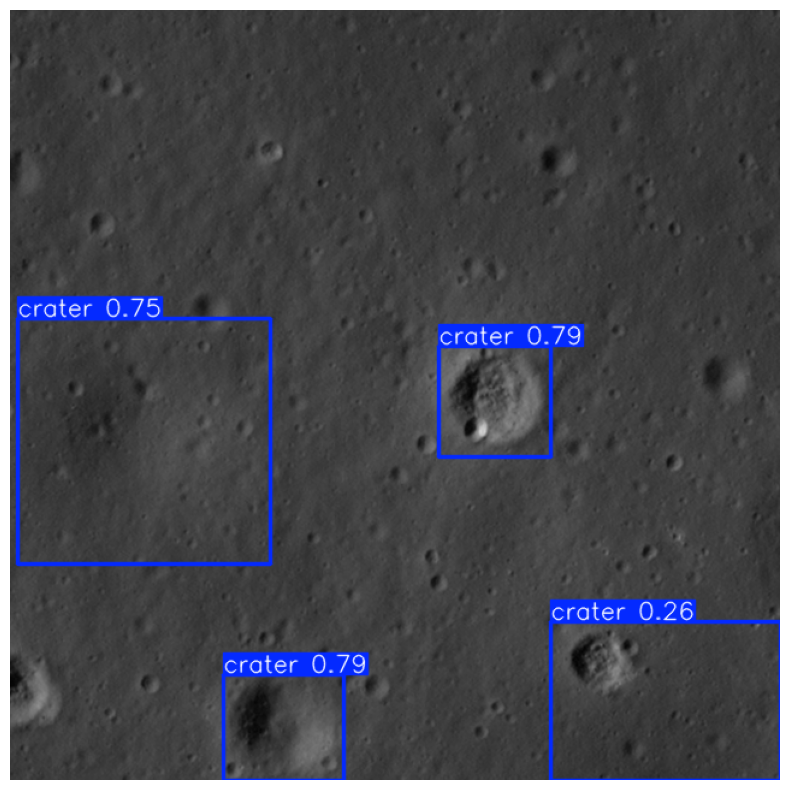

In [ ]:
from ultralytics import YOLO
import cv2
import os
import glob
from IPython.display import Image, display
import matplotlib.pyplot as plt

model = YOLO(MODEL_PATH)
results = model.predict(
    source=TEST_IMAGES_DIR,
    project=OUTPUT_PREDICT_DIR,
    name=PREDICT_NAME,
    save=False,
    save_txt=False,
    conf=0.25,
    iou=0.5,
    imgsz=640,
    device=0,
)

r = results[0]
img = r.plot()
out_path = f"/content/{DATA_NAME}_{PREDICT_NAME}_pred.png"
cv2.imwrite(str(out_path), img)

plt.figure(figsize=(10, 10))
plt.imshow(img[..., ::-1])
plt.axis("off")
plt.show()

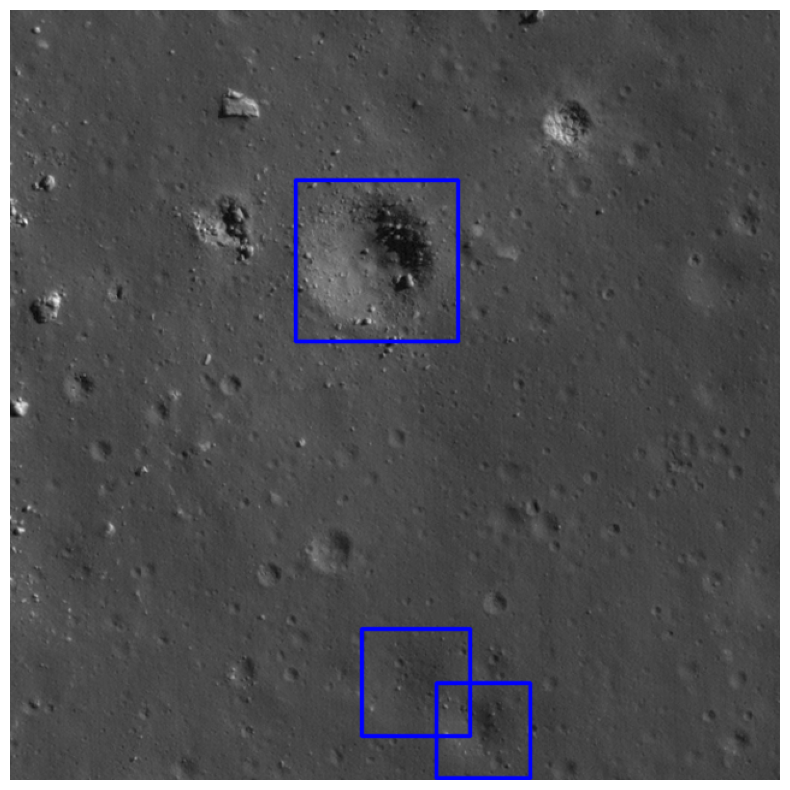

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from ultralytics.utils.plotting import Annotator

im = cv2.imread(str(TEST_IMAGES_DIR))
h, w = im.shape[:2]
ann = Annotator(im, example="")

for line in Path(TEST_LABELS_DIR).read_text().strip().splitlines():
    cls, xc, yc, bw, bh = map(float, line.split()[:5])
    x1 = (xc - bw / 2) * w
    y1 = (yc - bh / 2) * h
    x2 = (xc + bw / 2) * w
    y2 = (yc + bh / 2) * h

    ann.box_label([x1, y1, x2, y2], "", color=(255, 0, 0))

img = ann.result()
out_path = f"/content/{DATA_NAME}_GT.png"
cv2.imwrite(str(out_path), img)

plt.figure(figsize=(10, 10))
plt.imshow(img[..., ::-1])
plt.axis("off")
plt.show()
